#### this is a placeholder version. please see final version.

Model training complete!

             STATISTICAL EVALUATION             
Mean Absolute Error (MAE):      0.02761
Median Absolute Error (MedAE):  0.00416 (Robust to outliers)
Mean Absolute % Error (MAPE):   418.69%
Mean Squared Error (MSE):       0.00522
Root Mean Squared Error (RMSE): 0.07223
Maximum Prediction Error:       0.60496 (Worst single error)
--------------------------------------------------
Training R² Score:              0.97930
Training Adjusted R² Score:     0.97858
Testing R² Score (Accuracy):    0.97196
Testing Adjusted R² Score:      0.96756
Explained Variance Score:       0.97210
--------------------------------------------------
Residuals Mean (Bias Check):    0.00507 (Should be close to 0)
Residuals Std Dev:              0.07206

Diagnostic plots successfully saved to model_diagnostics.png


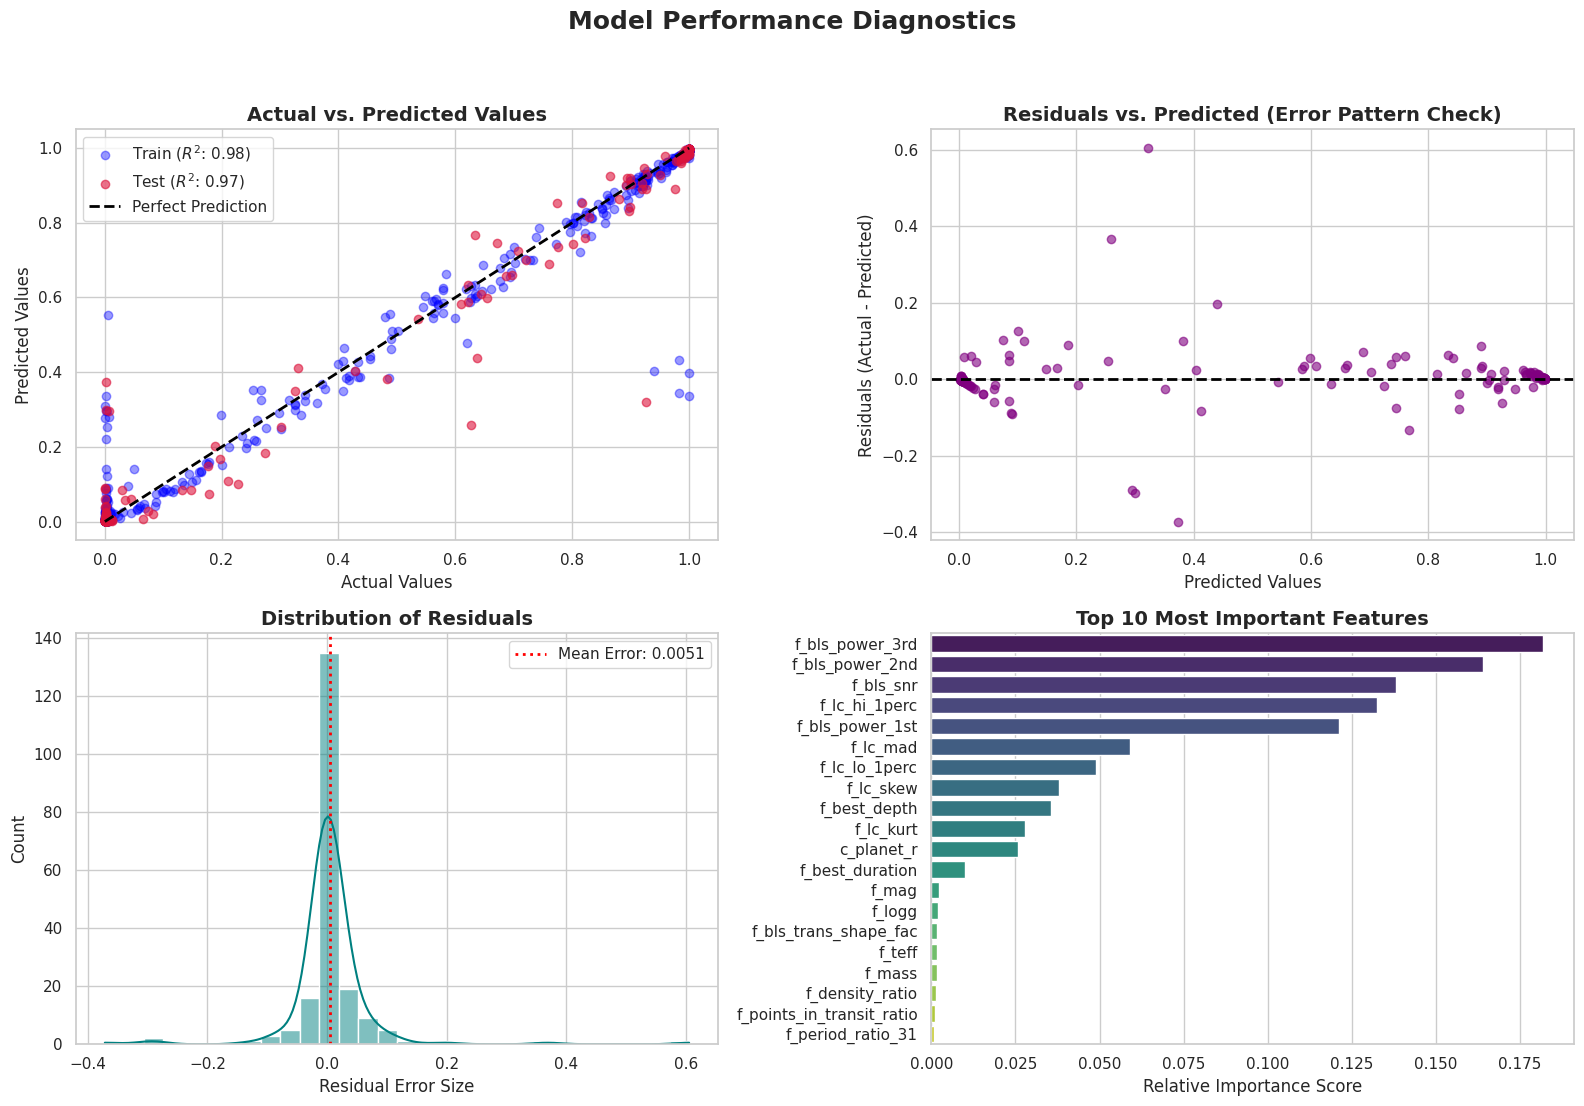

Model successfully saved to random_forest_model.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Added: mean_absolute_percentage_error, median_absolute_error, max_error, explained_variance_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                             mean_absolute_percentage_error, median_absolute_error, 
                             max_error, explained_variance_score)
import joblib

# Set seaborn style for clean, professional plots
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
df_features = pd.read_csv('newFeatures.csv')
df_truth = pd.read_csv('newTruth.csv')

# Define target features
feature_cols = [
    'f_best_depth', 'f_best_duration', 'f_best_initial','f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 
    'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 
    'f_bls_snr', 'f_bls_trans_shape_fac', 'f_density_ratio', 
    'f_dur_per_ratio', 'f_lc_hi_1perc', 'f_lc_kurt', 
    'f_lc_lo_1perc', 'f_lc_mad', 'f_lc_skew', 
    'f_logg', 'f_mag', 'f_mass', 'f_period_ratio_21', 
    'f_period_ratio_31', 'f_points_in_transit_ratio', 'f_teff', 'c_planet_r'
]

# Robust filtering using .values to prevent cross-dataframe index mismatch
goodness_mask = ((df_features['path'].str.contains('train'))).values

X = df_features.iloc[goodness_mask][feature_cols]
y = df_truth.iloc[goodness_mask]['p_H'].values.ravel()

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Initialize and Train the Model ---
# Note: max_depth=5 is quite shallow; if it underfits, consider bumping to 10-15
rf_model = RandomForestRegressor(
    n_estimators=200,     
    max_depth=10,         
    min_samples_leaf=2,   
    max_features='sqrt',  
    random_state=123,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model training complete!\n")

# --- 4. Statistical Evaluation ---
print("="*50)
print("             STATISTICAL EVALUATION             ")
print("="*50)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

residuals = y_test - y_test_pred
residual_mean = np.mean(residuals)
residual_std = np.std(residuals)

# --- NEW METRICS CALCULATIONS ---
mape = mean_absolute_percentage_error(y_test, y_test_pred)
medae = median_absolute_error(y_test, y_test_pred)
max_err = max_error(y_test, y_test_pred)
exp_var = explained_variance_score(y_test, y_test_pred)

# Degrees of freedom dimensions for Adjusted R²
n_train, p_features = X_train.shape[0], X_train.shape[1]
n_test = X_test.shape[0]

adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_features - 1)
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_features - 1)
# --------------------------------

print(f"Mean Absolute Error (MAE):      {mae:.5f}")
print(f"Median Absolute Error (MedAE):  {medae:.5f} (Robust to outliers)")
print(f"Mean Absolute % Error (MAPE):   {mape * 100:.2f}%")
print(f"Mean Squared Error (MSE):       {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"Maximum Prediction Error:       {max_err:.5f} (Worst single error)")
print("-" * 50)
print(f"Training R² Score:              {r2_train:.5f}")
print(f"Training Adjusted R² Score:     {adj_r2_train:.5f}")
print(f"Testing R² Score (Accuracy):    {r2_test:.5f}")
print(f"Testing Adjusted R² Score:      {adj_r2_test:.5f}")
print(f"Explained Variance Score:       {exp_var:.5f}")
print("-" * 50)
print(f"Residuals Mean (Bias Check):    {residual_mean:.5f} (Should be close to 0)")
print(f"Residuals Std Dev:              {residual_std:.5f}")
print("="*50)

# --- 5. Comprehensive Graphical Diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Diagnostics', fontsize=18, fontweight='bold', y=0.95)

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_train, y_train_pred, color='blue', alpha=0.4, label=f'Train ($R^2$: {r2_train:.2f})')
axes[0, 0].scatter(y_test, y_test_pred, color='crimson', alpha=0.6, label=f'Test ($R^2$: {r2_test:.2f})')
perfect_line = [min(y.min(), y_test_pred.min()), max(y.max(), y_test_pred.max())]
axes[0, 0].plot(perfect_line, perfect_line, color='black', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=12)
axes[0, 0].set_ylabel('Predicted Values', fontsize=12)
axes[0, 0].set_title('Actual vs. Predicted Values', fontsize=14, fontweight='semibold')
axes[0, 0].legend()

# Plot 2: Residuals vs Predicted (Heteroscedasticity check)
axes[0, 1].scatter(y_test_pred, residuals, color='purple', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residuals vs. Predicted (Error Pattern Check)', fontsize=14, fontweight='semibold')

# Plot 3: Distribution of Residuals (Normality check)
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='teal', bins=30)
axes[1, 0].axvline(x=residual_mean, color='red', linestyle=':', linewidth=2, label=f'Mean Error: {residual_mean:.4f}')
axes[1, 0].set_xlabel('Residual Error Size', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='semibold')
axes[1, 0].legend()

# Plot 4: Top 10 Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Take top 10
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

sns.barplot(x=top_importances, y=top_features, ax=axes[1, 1], hue=top_features, palette='viridis', legend=False)
axes[1, 1].set_xlabel('Relative Importance Score', fontsize=12)
axes[1, 1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='semibold')

# Clean layout management
plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# Save and Show plots
plot_filename = 'model_diagnostics.png'
plt.savefig(plot_filename, dpi=300)
print(f"\nDiagnostic plots successfully saved to {plot_filename}")
plt.show()

# --- 6. Save Model ---
model_filename = 'random_forest_model.pkl'
joblib.dump(rf_model, model_filename)
print(f"Model successfully saved to {model_filename}")

Model training complete!

             STATISTICAL EVALUATION             
Mean Absolute Error (MAE):      0.15143
Median Absolute Error (MedAE):  0.11140 (Robust to outliers)
Mean Absolute % Error (MAPE):   51.91%
Mean Squared Error (MSE):       0.03396
Root Mean Squared Error (RMSE): 0.18427
Maximum Prediction Error:       0.44469 (Worst single error)
--------------------------------------------------
Training R² Score:              0.82759
Training Adjusted R² Score:     0.79285
Testing R² Score (Accuracy):    0.39706
Testing Adjusted R² Score:      -0.85520
Explained Variance Score:       0.40348
--------------------------------------------------
Residuals Mean (Bias Check):    -0.01901 (Should be close to 0)
Residuals Std Dev:              0.18329

Diagnostic plots successfully saved to model_diagnostics.png


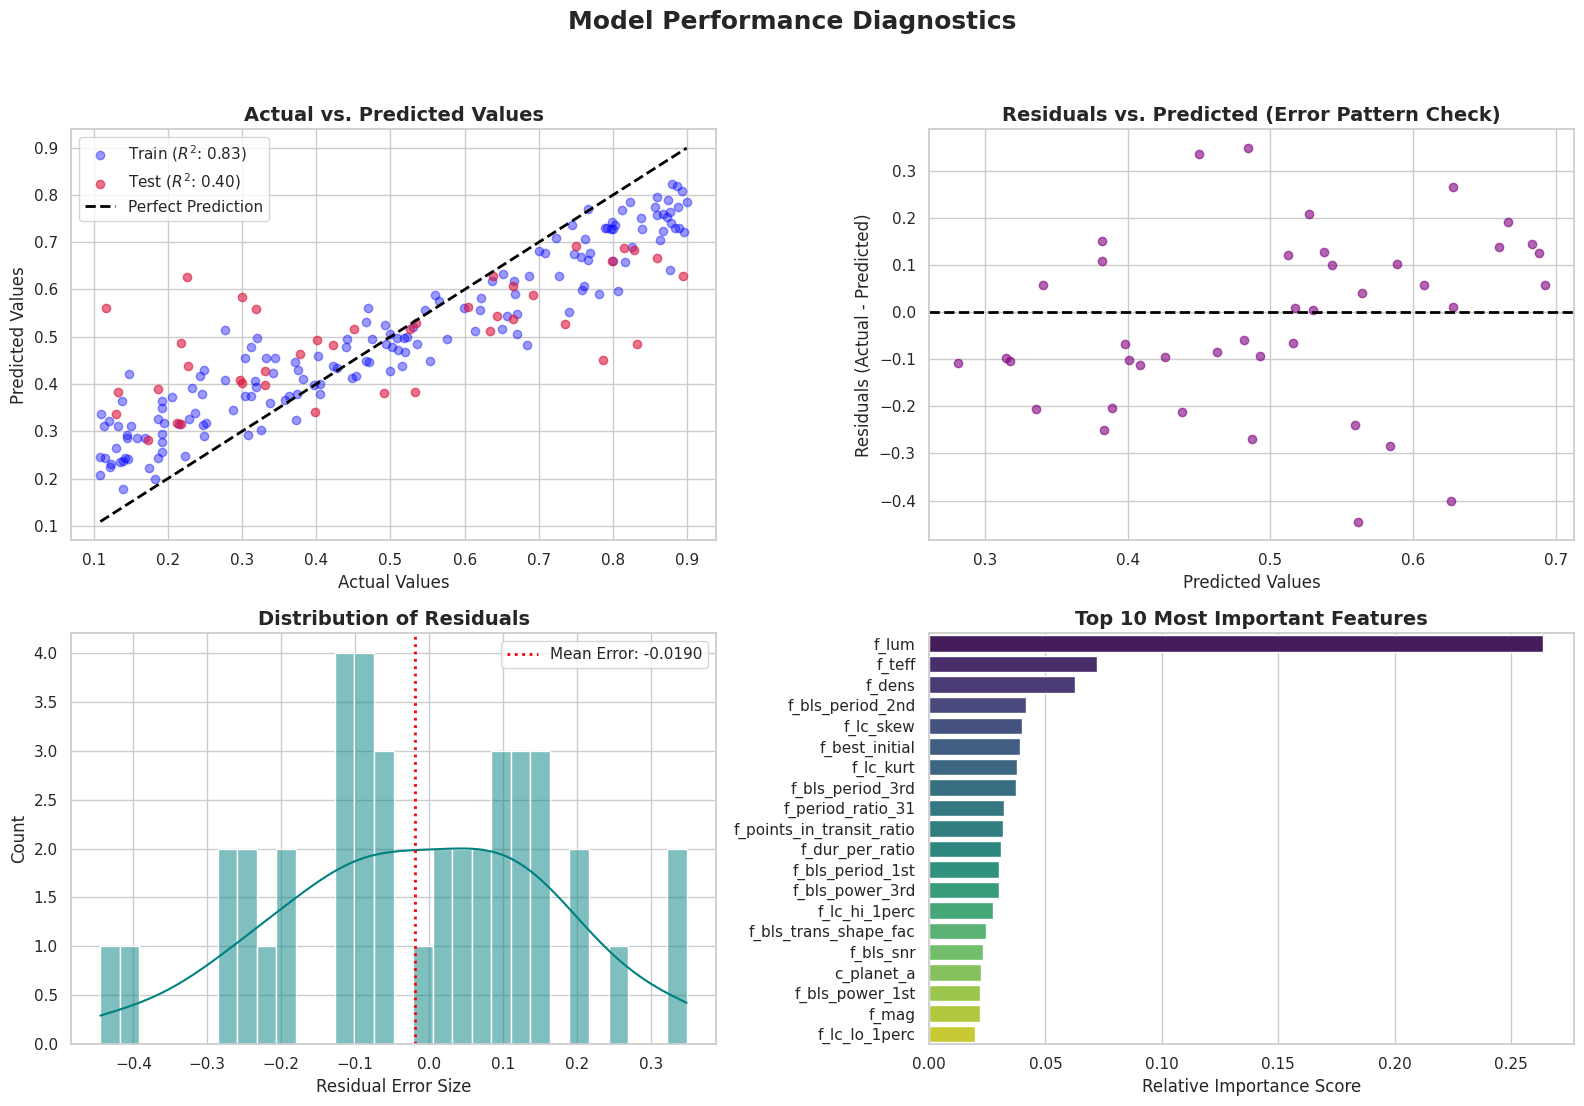

Model successfully saved to random_forest_model.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Added: mean_absolute_percentage_error, median_absolute_error, max_error, explained_variance_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                             mean_absolute_percentage_error, median_absolute_error, 
                             max_error, explained_variance_score)
import joblib

# Set seaborn style for clean, professional plots
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
df_features = pd.read_csv('newFeatures.csv')
df_truth = pd.read_csv('newTruth.csv')

# Define target features
feature_cols = [
    'f_best_depth', 'f_best_duration', 'f_best_initial','f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 
    'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 
    'f_bls_snr', 'f_bls_trans_shape_fac', 'f_density_ratio', 
    'f_dur_per_ratio', 'f_lc_hi_1perc', 'f_lc_kurt', 
    'f_lc_lo_1perc', 'f_lc_mad', 'f_lc_skew', 
    'f_mag', 'f_lum', 'f_period_ratio_21', 
    'f_period_ratio_31', 'f_points_in_transit_ratio', 'f_teff', 'f_dens', 'c_planet_a'
]

# Robust filtering using .values to prevent cross-dataframe index mismatch
goodness_mask = ((df_features['path'].str.contains('train')) & (np.abs(0.5 - df_truth['p_T']) <= 0.4)).values

X = df_features.iloc[goodness_mask][feature_cols]
y = df_truth.iloc[goodness_mask]['p_T'].values.ravel()

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Initialize and Train the Model ---
# Note: max_depth=5 is quite shallow; if it underfits, consider bumping to 10-15
rf_model = RandomForestRegressor(
    n_estimators=20,     
    max_depth=100,         
    min_samples_leaf=2,   
    max_features='sqrt',  
    random_state=123,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model training complete!\n")

# --- 4. Statistical Evaluation ---
print("="*50)
print("             STATISTICAL EVALUATION             ")
print("="*50)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

residuals = y_test - y_test_pred
residual_mean = np.mean(residuals)
residual_std = np.std(residuals)

# --- NEW METRICS CALCULATIONS ---
mape = mean_absolute_percentage_error(y_test, y_test_pred)
medae = median_absolute_error(y_test, y_test_pred)
max_err = max_error(y_test, y_test_pred)
exp_var = explained_variance_score(y_test, y_test_pred)

# Degrees of freedom dimensions for Adjusted R²
n_train, p_features = X_train.shape[0], X_train.shape[1]
n_test = X_test.shape[0]

adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_features - 1)
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_features - 1)
# --------------------------------

print(f"Mean Absolute Error (MAE):      {mae:.5f}")
print(f"Median Absolute Error (MedAE):  {medae:.5f} (Robust to outliers)")
print(f"Mean Absolute % Error (MAPE):   {mape * 100:.2f}%")
print(f"Mean Squared Error (MSE):       {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"Maximum Prediction Error:       {max_err:.5f} (Worst single error)")
print("-" * 50)
print(f"Training R² Score:              {r2_train:.5f}")
print(f"Training Adjusted R² Score:     {adj_r2_train:.5f}")
print(f"Testing R² Score (Accuracy):    {r2_test:.5f}")
print(f"Testing Adjusted R² Score:      {adj_r2_test:.5f}")
print(f"Explained Variance Score:       {exp_var:.5f}")
print("-" * 50)
print(f"Residuals Mean (Bias Check):    {residual_mean:.5f} (Should be close to 0)")
print(f"Residuals Std Dev:              {residual_std:.5f}")
print("="*50)

# --- 5. Comprehensive Graphical Diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Diagnostics', fontsize=18, fontweight='bold', y=0.95)

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_train, y_train_pred, color='blue', alpha=0.4, label=f'Train ($R^2$: {r2_train:.2f})')
axes[0, 0].scatter(y_test, y_test_pred, color='crimson', alpha=0.6, label=f'Test ($R^2$: {r2_test:.2f})')
perfect_line = [min(y.min(), y_test_pred.min()), max(y.max(), y_test_pred.max())]
axes[0, 0].plot(perfect_line, perfect_line, color='black', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=12)
axes[0, 0].set_ylabel('Predicted Values', fontsize=12)
axes[0, 0].set_title('Actual vs. Predicted Values', fontsize=14, fontweight='semibold')
axes[0, 0].legend()

# Plot 2: Residuals vs Predicted (Heteroscedasticity check)
axes[0, 1].scatter(y_test_pred, residuals, color='purple', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residuals vs. Predicted (Error Pattern Check)', fontsize=14, fontweight='semibold')

# Plot 3: Distribution of Residuals (Normality check)
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='teal', bins=30)
axes[1, 0].axvline(x=residual_mean, color='red', linestyle=':', linewidth=2, label=f'Mean Error: {residual_mean:.4f}')
axes[1, 0].set_xlabel('Residual Error Size', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='semibold')
axes[1, 0].legend()

# Plot 4: Top 10 Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Take top 10
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

sns.barplot(x=top_importances, y=top_features, ax=axes[1, 1], hue=top_features, palette='viridis', legend=False)
axes[1, 1].set_xlabel('Relative Importance Score', fontsize=12)
axes[1, 1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='semibold')

# Clean layout management
plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# Save and Show plots
plot_filename = 'model_diagnostics.png'
plt.savefig(plot_filename, dpi=300)
print(f"\nDiagnostic plots successfully saved to {plot_filename}")
plt.show()

# --- 6. Save Model ---
model_filename = 'random_forest_model.pkl'
joblib.dump(rf_model, model_filename)
print(f"Model successfully saved to {model_filename}")

Model training complete!

             STATISTICAL EVALUATION             
Mean Absolute Error (MAE):      0.23628
Median Absolute Error (MedAE):  0.24320 (Robust to outliers)
Mean Absolute % Error (MAPE):   94.84%
Mean Squared Error (MSE):       0.08409
Root Mean Squared Error (RMSE): 0.28998
Maximum Prediction Error:       0.56674 (Worst single error)
--------------------------------------------------
Training R² Score:              0.72993
Training Adjusted R² Score:     0.68032
Testing R² Score (Accuracy):    -0.20755
Testing Adjusted R² Score:      -2.24529
Explained Variance Score:       -0.13577
--------------------------------------------------
Residuals Mean (Bias Check):    -0.07070 (Should be close to 0)
Residuals Std Dev:              0.28123

Diagnostic plots successfully saved to model_diagnostics.png


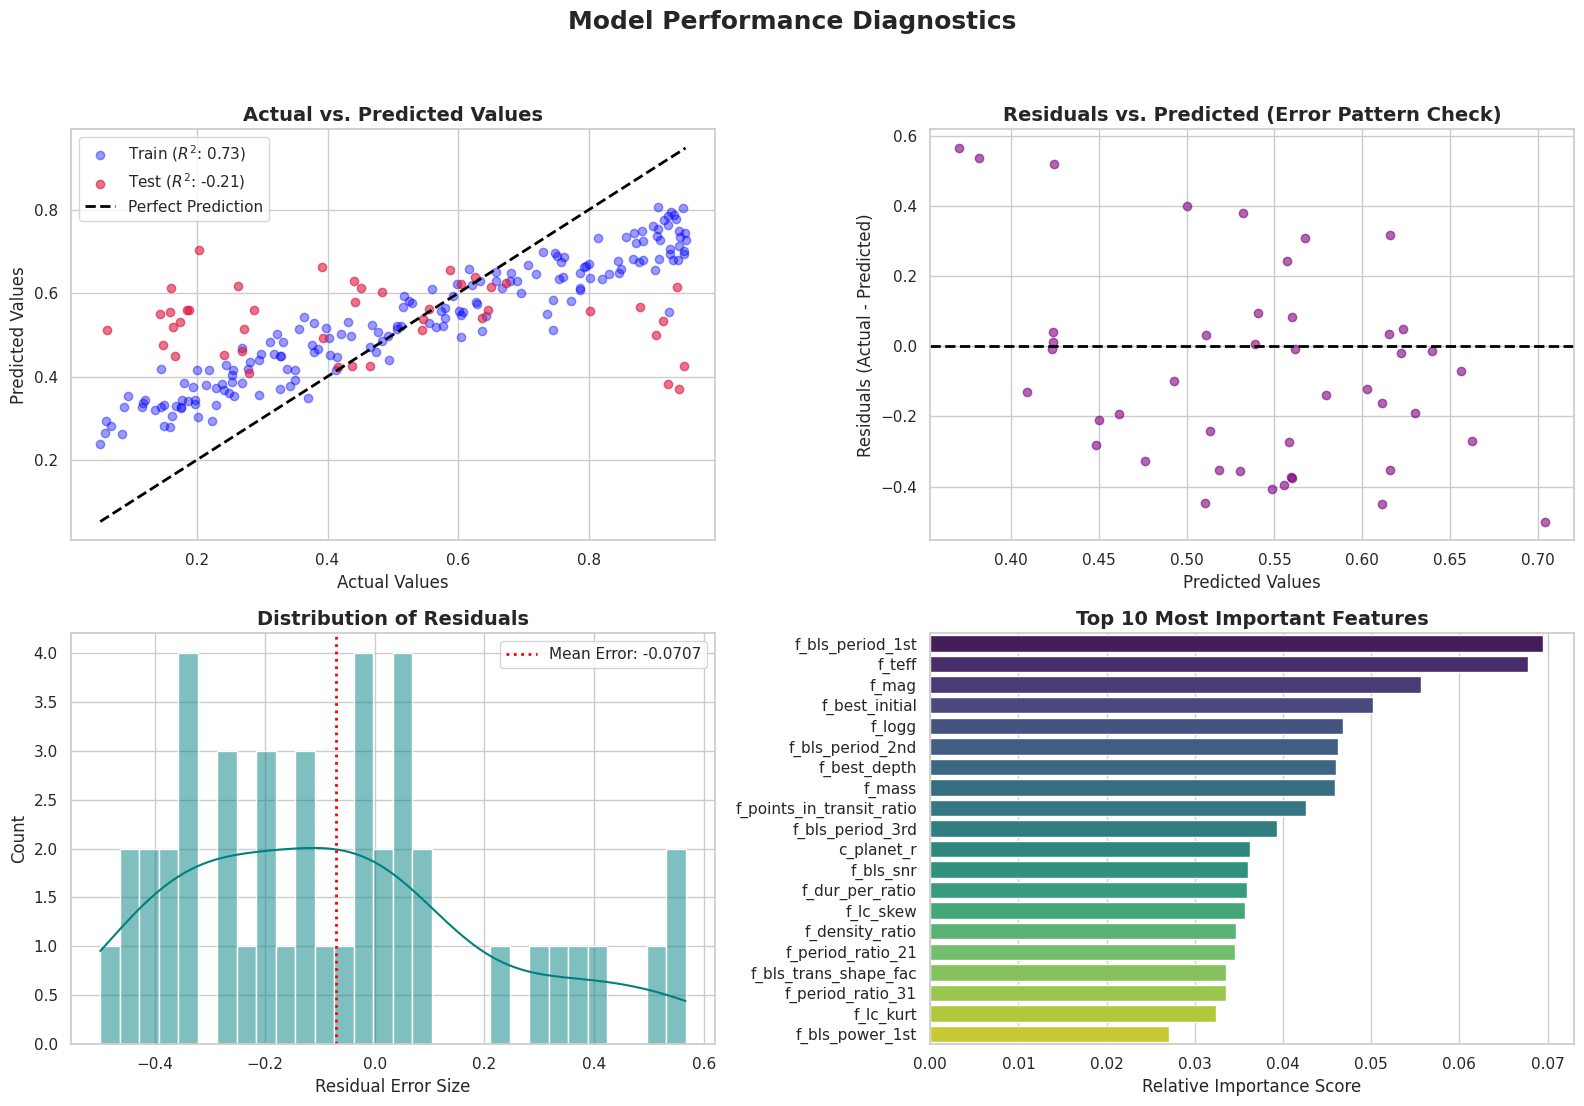

Model successfully saved to random_forest_model.pkl


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Added: mean_absolute_percentage_error, median_absolute_error, max_error, explained_variance_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, 
                             mean_absolute_percentage_error, median_absolute_error, 
                             max_error, explained_variance_score)
import joblib

# Set seaborn style for clean, professional plots
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
df_features = pd.read_csv('newFeatures.csv')
df_truth = pd.read_csv('newTruth.csv')

# Define target features
feature_cols = [
    'f_best_depth', 'f_best_duration', 'f_best_initial','f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 
    'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 
    'f_bls_snr', 'f_bls_trans_shape_fac', 'f_density_ratio', 
    'f_dur_per_ratio', 'f_lc_hi_1perc', 'f_lc_kurt', 
    'f_lc_lo_1perc', 'f_lc_mad', 'f_lc_skew', 
    'f_logg', 'f_mag', 'f_mass', 'f_period_ratio_21', 
    'f_period_ratio_31', 'f_points_in_transit_ratio', 'f_teff', 'c_planet_r'
]

# Robust filtering using .values to prevent cross-dataframe index mismatch
goodness_mask = ((df_features['path'].str.contains('train')) & (np.abs(0.5 - df_truth['p_R']) < 0.45)).values

X = df_features.iloc[goodness_mask][feature_cols]
y = df_truth.iloc[goodness_mask]['p_R'].values.ravel()

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Initialize and Train the Model ---
# Note: max_depth=5 is quite shallow; if it underfits, consider bumping to 10-15
rf_model = RandomForestRegressor(
    n_estimators=200,     
    max_depth=10,         
    min_samples_leaf=2,   
    max_features='sqrt',  
    random_state=123,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model training complete!\n")

# --- 4. Statistical Evaluation ---
print("="*50)
print("             STATISTICAL EVALUATION             ")
print("="*50)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

residuals = y_test - y_test_pred
residual_mean = np.mean(residuals)
residual_std = np.std(residuals)

# --- NEW METRICS CALCULATIONS ---
mape = mean_absolute_percentage_error(y_test, y_test_pred)
medae = median_absolute_error(y_test, y_test_pred)
max_err = max_error(y_test, y_test_pred)
exp_var = explained_variance_score(y_test, y_test_pred)

# Degrees of freedom dimensions for Adjusted R²
n_train, p_features = X_train.shape[0], X_train.shape[1]
n_test = X_test.shape[0]

adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_features - 1)
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_features - 1)
# --------------------------------

print(f"Mean Absolute Error (MAE):      {mae:.5f}")
print(f"Median Absolute Error (MedAE):  {medae:.5f} (Robust to outliers)")
print(f"Mean Absolute % Error (MAPE):   {mape * 100:.2f}%")
print(f"Mean Squared Error (MSE):       {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"Maximum Prediction Error:       {max_err:.5f} (Worst single error)")
print("-" * 50)
print(f"Training R² Score:              {r2_train:.5f}")
print(f"Training Adjusted R² Score:     {adj_r2_train:.5f}")
print(f"Testing R² Score (Accuracy):    {r2_test:.5f}")
print(f"Testing Adjusted R² Score:      {adj_r2_test:.5f}")
print(f"Explained Variance Score:       {exp_var:.5f}")
print("-" * 50)
print(f"Residuals Mean (Bias Check):    {residual_mean:.5f} (Should be close to 0)")
print(f"Residuals Std Dev:              {residual_std:.5f}")
print("="*50)

# --- 5. Comprehensive Graphical Diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Diagnostics', fontsize=18, fontweight='bold', y=0.95)

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_train, y_train_pred, color='blue', alpha=0.4, label=f'Train ($R^2$: {r2_train:.2f})')
axes[0, 0].scatter(y_test, y_test_pred, color='crimson', alpha=0.6, label=f'Test ($R^2$: {r2_test:.2f})')
perfect_line = [min(y.min(), y_test_pred.min()), max(y.max(), y_test_pred.max())]
axes[0, 0].plot(perfect_line, perfect_line, color='black', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=12)
axes[0, 0].set_ylabel('Predicted Values', fontsize=12)
axes[0, 0].set_title('Actual vs. Predicted Values', fontsize=14, fontweight='semibold')
axes[0, 0].legend()

# Plot 2: Residuals vs Predicted (Heteroscedasticity check)
axes[0, 1].scatter(y_test_pred, residuals, color='purple', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residuals vs. Predicted (Error Pattern Check)', fontsize=14, fontweight='semibold')

# Plot 3: Distribution of Residuals (Normality check)
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='teal', bins=30)
axes[1, 0].axvline(x=residual_mean, color='red', linestyle=':', linewidth=2, label=f'Mean Error: {residual_mean:.4f}')
axes[1, 0].set_xlabel('Residual Error Size', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='semibold')
axes[1, 0].legend()

# Plot 4: Top 10 Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Take top 10
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

sns.barplot(x=top_importances, y=top_features, ax=axes[1, 1], hue=top_features, palette='viridis', legend=False)
axes[1, 1].set_xlabel('Relative Importance Score', fontsize=12)
axes[1, 1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='semibold')

# Clean layout management
plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# Save and Show plots
plot_filename = 'model_diagnostics.png'
plt.savefig(plot_filename, dpi=300)
print(f"\nDiagnostic plots successfully saved to {plot_filename}")
plt.show()

# --- 6. Save Model ---
model_filename = 'random_forest_model.pkl'
joblib.dump(rf_model, model_filename)
print(f"Model successfully saved to {model_filename}")

ALL KEYS IN FEATURE DATAFRAME:
['path', 'sim', 'f_best_depth', 'f_best_duration', 'f_best_initial', 'f_bls_num_actual', 'f_bls_num_expect', 'f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 'f_bls_snr', 'f_bls_trans_shape_fac', 'f_dens', 'f_density_ratio', 'f_dur_per_ratio', 'f_goodness_flag', 'f_lc_hi_1perc', 'f_lc_hi_5perc', 'f_lc_kurt', 'f_lc_lo_1perc', 'f_lc_lo_5perc', 'f_lc_mad', 'f_lc_rms', 'f_lc_skew', 'f_logg', 'f_lum', 'f_mag', 'f_mass', 'f_period_ratio_21', 'f_period_ratio_31', 'f_points_in_transit_ratio', 'f_radius', 'f_teff', 'c_R', 'c_S', 'c_T', 'c_planet_a', 'c_planet_i', 'c_planet_r', 'c_teq', 'c_xeff']

ALL KEYS IN TRUTH DATAFRAME:
['path', 'sim', 't_act_flare', 't_act_flare_amp', 't_act_flare_dur', 't_act_flare_per', 't_act_sigma', 't_act_spot', 't_act_tau', 't_planet', 't_planet_a', 't_planet_i', 't_planet_p', 't_planet_r', 'p_B', 'p_C', 'p_F', 'p_H', 'p_R', 'p_S', 'p_T', 'p_teq', 'p

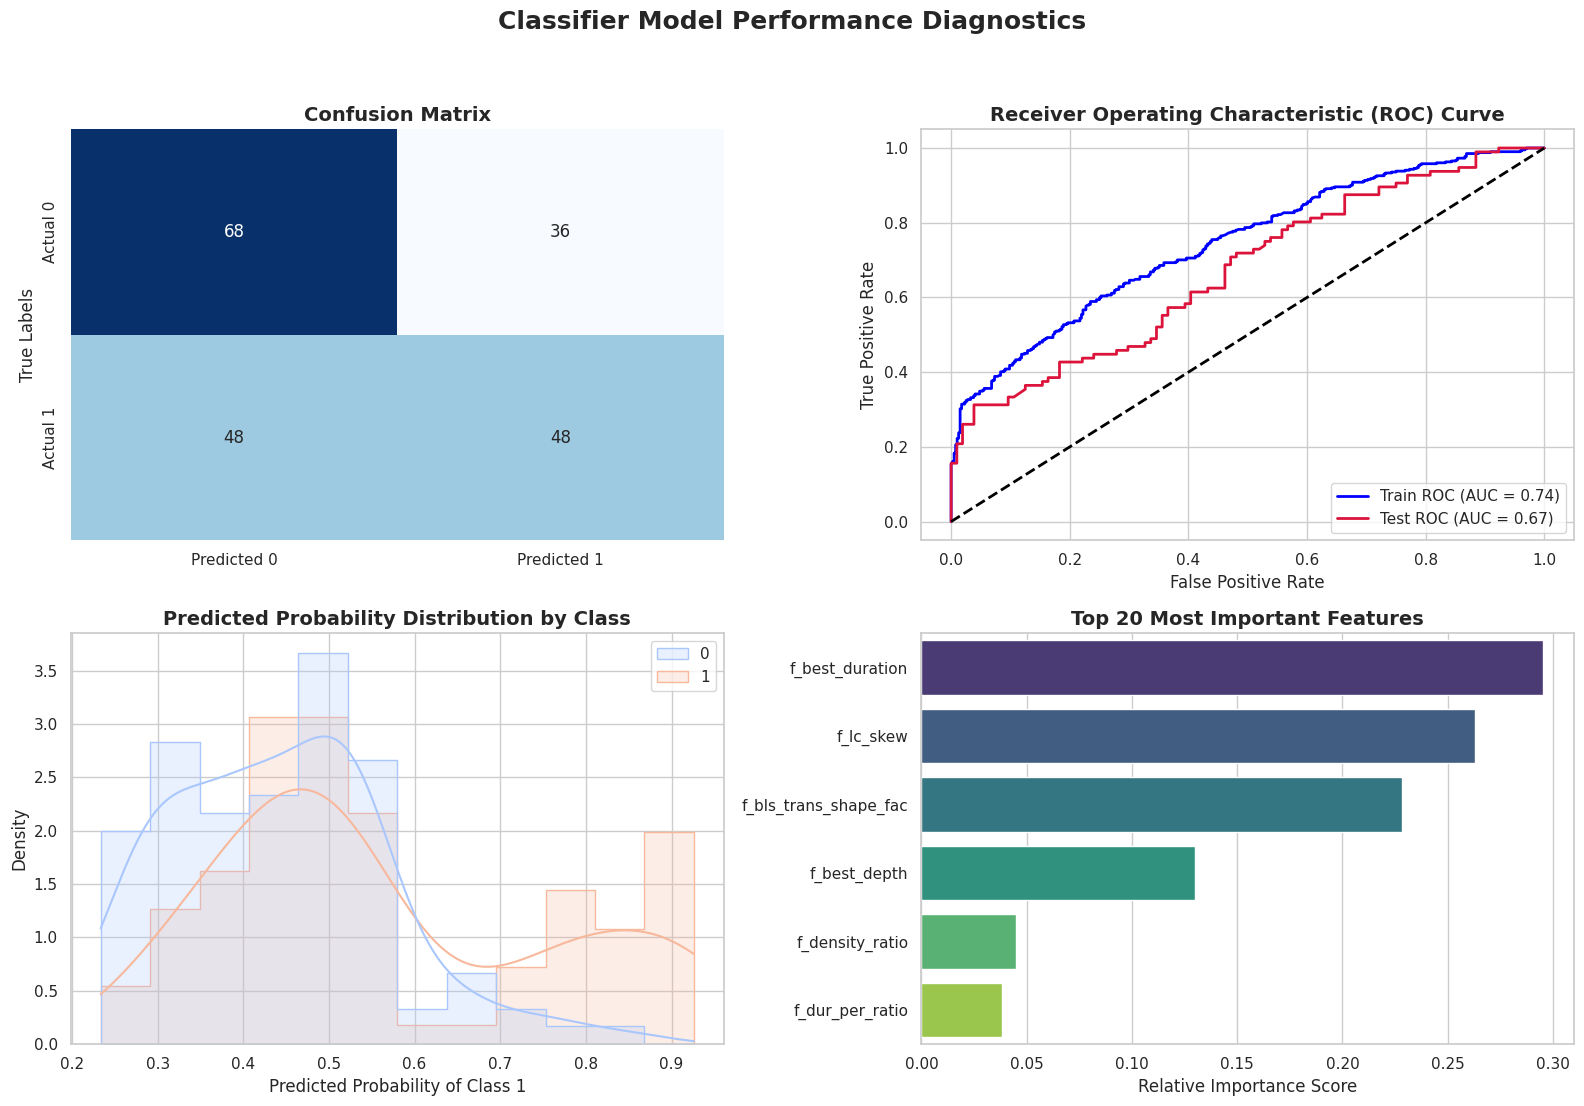

Model successfully saved to random_forest_model.pkl


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Swapped to Classifier
# Added classification metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve, classification_report)
import joblib

# Set seaborn style for clean, professional plots
sns.set_theme(style="whitegrid")

# --- 1. Load Data ---
df_features = pd.read_csv('newFeatures.csv')
df_truth = pd.read_csv('newTruth.csv')

# PRINT ALL KEYS (COLUMNS)
print("="*60)
print("ALL KEYS IN FEATURE DATAFRAME:")
print("="*60)
print(df_features.columns.tolist())
print("\n" + "="*60)
print("ALL KEYS IN TRUTH DATAFRAME:")
print("="*60)
print(df_truth.columns.tolist())
print("="*60 + "\n")

# Define target features
feature_cols = [
    'f_best_depth', 'f_best_duration', 'f_best_initial','f_bls_num_ratio', 'f_bls_period_1st', 'f_bls_period_2nd', 
    'f_bls_period_3rd', 'f_bls_power_1st', 'f_bls_power_2nd', 'f_bls_power_3rd', 
    'f_bls_snr', 'f_bls_trans_shape_fac', 'f_density_ratio', 
    'f_dur_per_ratio', 'f_lc_hi_1perc', 'f_lc_kurt', 
    'f_lc_lo_1perc', 'f_lc_mad', 'f_lc_skew', 
    'f_period_ratio_21', 
    'f_period_ratio_31', 'f_points_in_transit_ratio'
]
feature_cols = [
    'f_lc_skew', 
    'f_bls_trans_shape_fac', 
    'f_best_duration', 
    'f_density_ratio', 
    'f_best_depth',
    'f_dur_per_ratio'
]

# Robust filtering using .values to prevent cross-dataframe index mismatch
goodness_mask = ((df_features['path'].str.contains('train'))).values

X = df_features.iloc[goodness_mask][feature_cols]
y = df_truth.iloc[goodness_mask]['t_planet'].values.ravel() 

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Initialize and Train the Model ---
rf_model = RandomForestClassifier(
    n_estimators=100,     
    max_depth=3,           # Extremely shallow; forces simple, broad splits
    min_samples_leaf=45,   # Forces leaves to contain ~5-6% of the entire training set
    max_features=None,     
    class_weight='balanced',
    random_state=123,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model training complete!\n")

# --- 4. Statistical Evaluation ---
print("="*50)
print("             STATISTICAL EVALUATION             ")
print("="*50)

# Generate Class Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Generate Probability Predictions (needed for ROC-AUC and probability plots)
y_train_prob = rf_model.predict_proba(X_train)[:, 1]
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate Classification Metrics
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)

print(f"Training Accuracy Score:         {acc_train:.5f}")
print(f"Testing Accuracy Score (Acc):    {acc_test:.5f}")
print("-" * 50)
print(f"Testing Precision Score:         {precision:.5f} (When model says '1', accuracy)")
print(f"Testing Recall Score (Sens.):    {recall:.5f} (Out of all true '1's caught)")
print(f"Testing F1-Score:                {f1:.5f} (Harmonic mean of Prec/Rec)")
print(f"Testing ROC-AUC Score:           {roc_auc:.5f} (Separation power close to 1)")
print("="*50)

print("\nDetailed Scikit-Learn Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("="*50)

# --- 5. Comprehensive Graphical Diagnostics ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Classifier Model Performance Diagnostics', fontsize=18, fontweight='bold', y=0.95)

# Plot 1: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='semibold')
axes[0, 0].set_ylabel('True Labels')

# Plot 2: ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
axes[0, 1].plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Train ROC (AUC = {roc_auc_score(y_train, y_train_prob):.2f})')
axes[0, 1].plot(fpr_test, tpr_test, color='crimson', lw=2, label=f'Test ROC (AUC = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='semibold')
axes[0, 1].legend(loc='lower right')

# Plot 3: Distribution of Predicted Probabilities (Confidence Check)
sns.histplot(x=y_test_prob, hue=y_test, element='step', stat='density', common_norm=False, kde=True, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_xlabel('Predicted Probability of Class 1', fontsize=12)
axes[1, 0].set_title('Predicted Probability Distribution by Class', fontsize=14, fontweight='semibold')

# Plot 4: Top 20 Feature Importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  
top_features = [feature_cols[i] for i in indices]
top_importances = importances[indices]

sns.barplot(x=top_importances, y=top_features, ax=axes[1, 1], hue=top_features, palette='viridis', legend=False)
axes[1, 1].set_xlabel('Relative Importance Score', fontsize=12)
axes[1, 1].set_title('Top 20 Most Important Features', fontsize=14, fontweight='semibold')

# Clean layout management
plt.tight_layout(rect=[0, 0.03, 1, 0.92])

# Save and Show plots
plot_filename = 'model_diagnostics.png'
plt.savefig(plot_filename, dpi=300)
print(f"\nDiagnostic plots successfully saved to {plot_filename}")
plt.show()

# --- 6. Save Model ---
model_filename = 'random_forest_model.pkl'
joblib.dump(rf_model, model_filename)
print(f"Model successfully saved to {model_filename}")